## Task 4: Optimize Portfolio Based on Forecast

### 0. Load Historical Data and TSLA Forecast

We reload the cleaned historical data for all three assets, plus the TSLA
forecast results from Task 3 (mean forecast and lower bound), which will
be used to construct the expected-return assumption for TSLA.

In [6]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    combined_df = pd.read_csv('../data/processed/combined_assets.csv', parse_dates=['Date'])
    tickers = ['TSLA', 'BND', 'SPY']

    print(combined_df['Ticker'].unique())
    print(combined_df.groupby('Ticker')['Date'].agg(['min', 'max']))
except Exception as e:
    print(f"Error loading combined data: {e}")

<StringArray>
['BND', 'SPY', 'TSLA']
Length: 3, dtype: str
              min        max
Ticker                      
BND    2015-01-02 2026-06-29
SPY    2015-01-02 2026-06-29
TSLA   2015-01-02 2026-06-29


### 1. Reshape Data: Wide-Format Daily Returns

Portfolio optimization requires a returns matrix with one column per
asset. We pivot the long-format combined dataset into a wide format,
aligned by date, and compute daily returns for each asset.

In [5]:
try:
    price_wide = combined_df.pivot(index='Date', columns='Ticker', values='Adj Close')
    price_wide = price_wide[tickers].dropna()

    returns_wide = price_wide.pct_change().dropna()

    print(price_wide.tail())
    print(returns_wide.describe())
except Exception as e:
    print(f"Error reshaping data into wide format: {e}")

Ticker            TSLA        BND         SPY
Date                                         
2026-06-23  381.609985  72.976631  733.580017
2026-06-24  375.529999  73.305534  733.239990
2026-06-25  375.119995  73.355370  734.299988
2026-06-26  379.709991  73.425133  728.989990
2026-06-29  411.839996  73.465004  741.000000
Ticker         TSLA          BND          SPY
count   2887.000000  2887.000000  2887.000000
mean       0.001803     0.000079     0.000573
std        0.036018     0.003347     0.011121
min       -0.210628    -0.054385    -0.109424
25%       -0.016643    -0.001511    -0.003700
50%        0.001216     0.000134     0.000655
75%        0.019456     0.001773     0.005930
max        0.226900     0.042201     0.105019


### 2. Prepare Expected Returns

Per the project brief, TSLA's expected return uses the Task 3 forecast
rather than historical averages, while BND and SPY use historical average
daily returns (annualized). This simulates an analyst who has a specific
forward-looking view on one asset but relies on historical data for the
others.

Following the caution raised in Task 3 — that the raw mean forecast may
be too optimistic, reflecting TSLA's historically strong training-period
uptrend more than a validated forward view — we use a **conservative
blended estimate**: the average of the mean forecast and the lower bound
of the 95% confidence interval, rather than the raw mean alone. This
tempers the expected return input without discarding the forecast
entirely.

In [7]:
try:
    last_tsla_price = price_wide['TSLA'].iloc[-1]

    forecast_results = pd.read_csv('../data/processed/tsla_future_forecast.csv', parse_dates=['Date'])
    tsla_forecast_final_mean = forecast_results['Mean_Forecast'].iloc[-1]
    tsla_forecast_final_lower = forecast_results['Lower_Bound'].iloc[-1]

    conservative_tsla_price = (tsla_forecast_final_mean + tsla_forecast_final_lower) / 2
    tsla_expected_annual_return = (conservative_tsla_price / last_tsla_price) - 1

    trading_days = 252
    bnd_expected_annual_return = returns_wide['BND'].mean() * trading_days
    spy_expected_annual_return = returns_wide['SPY'].mean() * trading_days

    expected_returns = pd.Series({
        'TSLA': tsla_expected_annual_return,
        'BND': bnd_expected_annual_return,
        'SPY': spy_expected_annual_return
    })

    print("Expected Annual Returns:")
    print(expected_returns)
except Exception as e:
    print(f"Error preparing expected returns: {e}")

Expected Annual Returns:
TSLA    0.515714
BND     0.019957
SPY     0.144320
dtype: float64


### 3. Compute Covariance Matrix

The covariance matrix, calculated from historical daily returns and
annualized, captures how the three assets move together. This is
essential for estimating portfolio-level risk, since a portfolio's
volatility depends not just on individual asset volatilities but on how
they correlate.

In [8]:
try:
    cov_matrix_daily = returns_wide.cov()
    cov_matrix_annual = cov_matrix_daily * trading_days

    print("Annualized Covariance Matrix:")
    print(cov_matrix_annual)

    correlation_matrix = returns_wide.corr()
    print("\nCorrelation Matrix:")
    print(correlation_matrix)
except Exception as e:
    print(f"Error computing covariance matrix: {e}")

Annualized Covariance Matrix:
Ticker      TSLA       BND       SPY
Ticker                              
TSLA    0.326926  0.001803  0.049820
BND     0.001803  0.002823  0.001085
SPY     0.049820  0.001085  0.031169

Correlation Matrix:
Ticker      TSLA       BND       SPY
Ticker                              
TSLA    1.000000  0.059359  0.493535
BND     0.059359  1.000000  0.115709
SPY     0.493535  0.115709  1.000000


### 4. Visualize Covariance Matrix

A heatmap of the correlation matrix makes it easy to see diversification
potential at a glance. Low or negative correlation between assets (e.g.,
TSLA vs. BND) is what allows a portfolio to reduce risk through
diversification, since the assets don't move in lockstep.

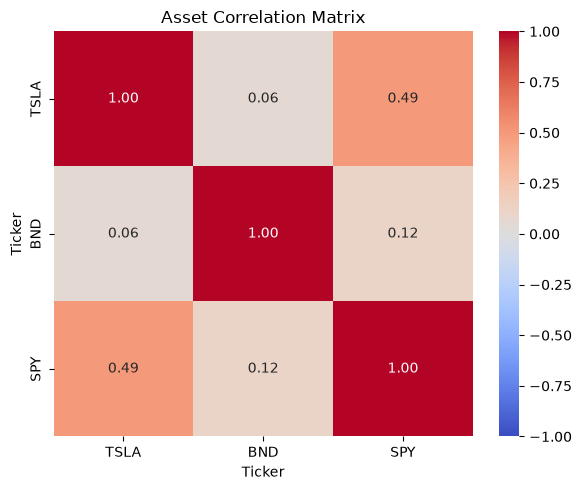

In [9]:
try:
    plt.figure(figsize=(6, 5))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Asset Correlation Matrix')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting correlation heatmap: {e}")

### 5. Generate the Efficient Frontier

We use `PyPortfolioOpt` to construct the efficient frontier from our
expected returns vector and covariance matrix. We also run a Monte Carlo
simulation of random portfolio weights as a visual backdrop, which helps
illustrate the frontier as the upper-left boundary of all achievable
risk/return combinations.

In [12]:
try:
    from pypfopt import EfficientFrontier
    from pypfopt import risk_models
    from pypfopt import expected_returns as pypfopt_returns

    risk_free_rate = 0.02

    # Random portfolio simulation for visualization
    n_portfolios = 5000
    n_assets = len(tickers)
    results = np.zeros((3, n_portfolios))
    weights_record = []

    np.random.seed(42)
    for i in range(n_portfolios):
        weights = np.random.random(n_assets)
        weights /= np.sum(weights)
        weights_record.append(weights)

        port_return = np.dot(weights, expected_returns.values)
        port_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_annual.values, weights)))
        sharpe = (port_return - risk_free_rate) / port_std

        results[0, i] = port_return
        results[1, i] = port_std
        results[2, i] = sharpe

    print(f"Simulated {n_portfolios} random portfolios.")
except Exception as e:
    print(f"Error generating random portfolio simulation: {e}")

Simulated 5000 random portfolios.


### 6. Identify Key Portfolios: Max Sharpe Ratio and Min Volatility

Using `PyPortfolioOpt`'s `EfficientFrontier` optimizer, we solve directly
for two key portfolios:
- **Maximum Sharpe Ratio Portfolio** (Tangency Portfolio): the portfolio
  offering the best risk-adjusted return
- **Minimum Volatility Portfolio**: the portfolio with the lowest possible
  risk, regardless of return

In [13]:
try:
    ef_max_sharpe = EfficientFrontier(expected_returns, cov_matrix_annual)
    ef_max_sharpe.max_sharpe(risk_free_rate=risk_free_rate)
    max_sharpe_weights = ef_max_sharpe.clean_weights()
    max_sharpe_perf = ef_max_sharpe.portfolio_performance(risk_free_rate=risk_free_rate)

    ef_min_vol = EfficientFrontier(expected_returns, cov_matrix_annual)
    ef_min_vol.min_volatility()
    min_vol_weights = ef_min_vol.clean_weights()
    min_vol_perf = ef_min_vol.portfolio_performance(risk_free_rate=risk_free_rate)

    print("Max Sharpe Ratio Portfolio:")
    print(f"  Weights: {max_sharpe_weights}")
    print(f"  Expected Return: {max_sharpe_perf[0]:.4f}, Volatility: {max_sharpe_perf[1]:.4f}, Sharpe: {max_sharpe_perf[2]:.4f}")

    print("\nMinimum Volatility Portfolio:")
    print(f"  Weights: {min_vol_weights}")
    print(f"  Expected Return: {min_vol_perf[0]:.4f}, Volatility: {min_vol_perf[1]:.4f}, Sharpe: {min_vol_perf[2]:.4f}")
except Exception as e:
    print(f"Error optimizing for max Sharpe / min volatility portfolios: {e}")

Max Sharpe Ratio Portfolio:
  Weights: OrderedDict({'TSLA': 0.36728, 'BND': 0.0, 'SPY': 0.63272})
  Expected Return: 0.2807, Volatility: 0.2824, Sharpe: 0.9233

Minimum Volatility Portfolio:
  Weights: OrderedDict({'TSLA': 0.0, 'BND': 0.94538, 'SPY': 0.05462})
  Expected Return: 0.0267, Volatility: 0.0522, Sharpe: 0.1292


### 7. Visualize Efficient Frontier

The scatter of randomly simulated portfolios shows the full universe of
achievable risk/return combinations, colored by Sharpe ratio. The Max
Sharpe and Min Volatility portfolios are marked explicitly, showing where
they sit relative to the broader opportunity set.

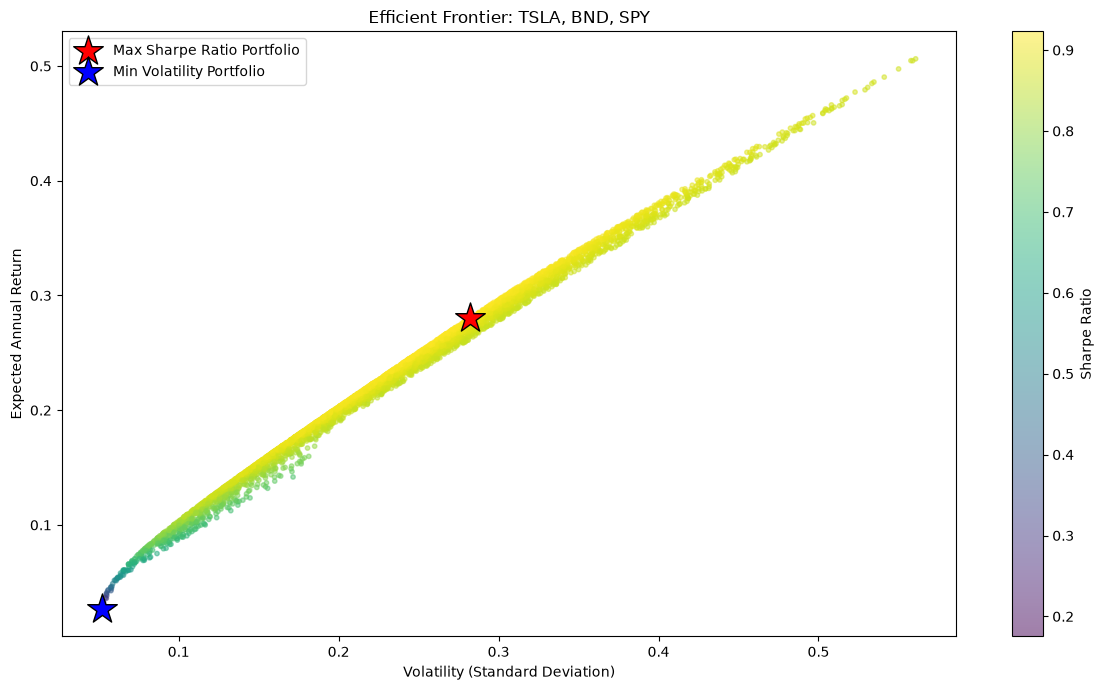

In [14]:
try:
    plt.figure(figsize=(12, 7))
    scatter = plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', alpha=0.5, s=10)
    plt.colorbar(scatter, label='Sharpe Ratio')

    plt.scatter(max_sharpe_perf[1], max_sharpe_perf[0], marker='*', color='red', s=500, label='Max Sharpe Ratio Portfolio', edgecolors='black')
    plt.scatter(min_vol_perf[1], min_vol_perf[0], marker='*', color='blue', s=500, label='Min Volatility Portfolio', edgecolors='black')

    plt.title('Efficient Frontier: TSLA, BND, SPY')
    plt.xlabel('Volatility (Standard Deviation)')
    plt.ylabel('Expected Annual Return')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting efficient frontier: {e}")